# Now the survey plan is to use MA table `IM_600_16` and do a few exposures (e.g., 5 exposures). I've simulated single 600s exposures. I need to dither them (by modifying the WCS) and write them into FITS files. These images will be put into DOLPHOT to do photometry, and understand background source density and star-galaxy separation.


In [17]:
# Import packages
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS

import asdf
from astropy.table import Table, vstack, Column, hstack
from astropy.visualization import simple_norm
import copy

import os, sys
# sys.path.append('/home/jiaxuanl/Research/Packages/romanisim/')
sys.path.append('/home/jiaxuanl/Research/Roman_Cycle1/')
os.chdir('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/')
os.environ['NUMEXPR_MAX_THREADS'] = "30"
from kuaizi.display import display_single

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
host = 'NGC253'
obs_ra, obs_dec = 11.8880580, -25.2888000 # NGC 253

In [4]:
from ripples.fields import get_subpixel_dither

In [13]:
'.'.join(['dfsdf', ''])

'dfsdf.'

Dither in pixels:
 [[0.         0.        ]
 [0.54545455 0.        ]
 [0.54545455 0.45454545]
 [0.         0.45454545]
 [0.27272727 0.72727273]]


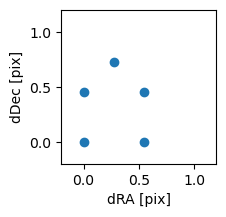

[(np.float64(0.0), np.float64(0.0)),
 (np.float64(1.8433191867994655e-05), np.float64(0.0)),
 (np.float64(1.8433191867986974e-05), np.float64(1.3888888888890152e-05)),
 (np.float64(0.0), np.float64(1.3888888888883206e-05)),
 (np.float64(9.216595933993487e-06), np.float64(2.2222222222222853e-05))]

In [10]:
get_subpixel_dither(obs_ra, obs_dec, pattern='BOXGAP5_1')

Dither in pixels:
 [[0.   0.  ]
 [0.25 0.75]
 [0.75 0.5 ]
 [0.5  0.75]]


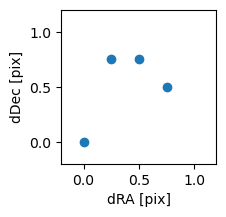

[(np.float64(0.0), np.float64(0.0)),
 (np.float64(8.448546272828002e-06), np.float64(2.2916666666666667e-05)),
 (np.float64(2.5345638818484007e-05), np.float64(1.5277777777777777e-05)),
 (np.float64(1.6897092545656005e-05), np.float64(2.2916666666666667e-05))]

In [15]:
get_subpixel_dither(obs_ra, obs_dec, pattern='SUB4')

Dither in pixels:
 [[0.         0.        ]
 [0.09090909 0.90909091]
 [0.63636364 0.36363636]
 [0.18181818 0.81818182]
 [0.27272727 0.72727273]]


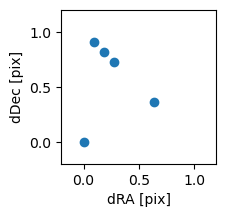

[(np.float64(0.0), np.float64(0.0)),
 (np.float64(3.072198644661934e-06), np.float64(2.7777777777780303e-05)),
 (np.float64(2.150539051265659e-05), np.float64(1.1111111111107954e-05)),
 (np.float64(6.144397289323868e-06), np.float64(2.5000000000005053e-05)),
 (np.float64(9.21659593400117e-06), np.float64(2.2222222222215908e-05))]

In [14]:
get_subpixel_dither(obs_ra, obs_dec, pattern='LINEGAP5_1')

In [85]:
import artpop
import rosesim
from rosesim.rose import RomanGalaxy, RomanSky
rng = np.random.RandomState(100)

In [87]:
for filt in ['F106', 'F158']:
    for i in range(5):
        dm = rosesim.read_L3_asdf(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_cena/{filt}_600s_LINEGAP5_1.{i}.asdf')
        rosesim.utils.asdf_to_fits(dm, f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_cena/{filt}_600s_LINEGAP5_1.{i}.fits', subtract_bkg=False)

Successfully wrote FITS file: /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_cena/F106_600s_LINEGAP5_1.0.fits
Successfully wrote FITS file: /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_cena/F106_600s_LINEGAP5_1.1.fits


Successfully wrote FITS file: /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_cena/F106_600s_LINEGAP5_1.2.fits
Successfully wrote FITS file: /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_cena/F106_600s_LINEGAP5_1.3.fits


Successfully wrote FITS file: /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_cena/F106_600s_LINEGAP5_1.4.fits
Successfully wrote FITS file: /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_cena/F158_600s_LINEGAP5_1.0.fits


Successfully wrote FITS file: /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_cena/F158_600s_LINEGAP5_1.1.fits
Successfully wrote FITS file: /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_cena/F158_600s_LINEGAP5_1.2.fits


Successfully wrote FITS file: /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_cena/F158_600s_LINEGAP5_1.3.fits
Successfully wrote FITS file: /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_cena/F158_600s_LINEGAP5_1.4.fits


In [88]:
for filt in ['F106', 'F158']:
    for i in range(5):
        dm = rosesim.read_L3_asdf(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/{filt}_600s_LINEGAP5_1.{i}.asdf')
        rosesim.utils.asdf_to_fits(dm, f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/{filt}_600s_LINEGAP5_1.{i}.fits', subtract_bkg=False)

Successfully wrote FITS file: /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/F106_600s_LINEGAP5_1.0.fits
Successfully wrote FITS file: /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/F106_600s_LINEGAP5_1.1.fits


Successfully wrote FITS file: /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/F106_600s_LINEGAP5_1.2.fits
Successfully wrote FITS file: /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/F106_600s_LINEGAP5_1.3.fits


Successfully wrote FITS file: /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/F106_600s_LINEGAP5_1.4.fits
Successfully wrote FITS file: /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/F158_600s_LINEGAP5_1.0.fits


Successfully wrote FITS file: /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/F158_600s_LINEGAP5_1.1.fits
Successfully wrote FITS file: /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/F158_600s_LINEGAP5_1.2.fits


Successfully wrote FITS file: /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/F158_600s_LINEGAP5_1.3.fits
Successfully wrote FITS file: /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/F158_600s_LINEGAP5_1.4.fits


In [56]:
dm.data.shape

(4096, 4096)

In [91]:
data1 = fits.open('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_cena/F106_600s_LINEGAP5_1.0.fits')[0].data
data2 = fits.open('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_cena/F106_600s_LINEGAP5_1.1.fits')[0].data

In [ ]:
display_single(data1);

In [13]:
# This location is centered at NGC 253
# The MW stars from TRILEGAL are actually around this location.
# obs_ra, obs_dec = 11.8880580, -25.2888000 # NGC 253
obs_ra, obs_dec = 201.3704160, -43.0166667 # cena

In [14]:
s = 501 # size of the frame
sky = RomanSky(obs_ra, obs_dec, xy_dim=np.array([s, s]), prefix='sky_jaguar_test')
radius = sky.xy_dim[0] * 0.11 / 3600
sky.obs_time = Time('2026-01-01T00:00:00') # this will affect the sky background level
# sky.load_gaia_star(radius=radius)
sky.load_trilegal_star(radius=radius, area=2, 
                       path='/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/TRILEGAL/trilegal_Roman_30mag_2deg2_CenA.dat')
sky.load_jaguar_bkg(radius=radius, seed=42)
sky.gen_catalog(include_bkg=False, include_star=True)

Warning -- need to figure out the coefficients between JWST and Roman filters.
5 star sources loaded.


Warning -- need to figure out the coefficients between JWST and Roman filters.
No sources to be included, so it will generate an empty sky.


Warning -- need to figure out the coefficients between JWST and Roman filters.
54 star sources loaded.


In [36]:
exptime = 11642 # HLWAS
# sky.observe('F158', exptime=exptime, fastpointsources=True, psftype='epsf')
sky.observe('F106', exptime=exptime, fastpointsources=True, psftype='galsim')
# sky.observe('F106', exptime=exptime)
# sky.observe('F129', exptime=exptime)

Making mock Roman L3 image in F106 for sky_jaguar_test


2026-02-19 14:50:52 INFO     Running with args: Namespace(filename='/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim//sky_jaguar_test/F106_11642s.asdf', catalog='/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim//sky_jaguar_test/temp/sky_table_sky_jaguar_test.ecsv', bandpass='F106', config=None, date='2026-01-01T00:00:00.000', radec=[201.370416, -43.0166667], npix=501, pixscalefrac=1.0, exptime=11642.0, effreadnoise=None, nexposures=6, rng_seed=0, psftype='galsim', fastpointsources=True)
2026-02-19 14:50:52 INFO     Starting simulation...
2026-02-19 14:50:52 INFO     Setting WCS reference to RA_ref=201.370416, Dec_ref=-43.0166667


2026-02-19 14:50:53 WARNING  Velocity aberration scale must be a positive number: -999999.0
2026-02-19 14:50:53 WARNING  Defaulting to scale of 1.0
2026-02-19 14:50:53 INFO     Simulating filter F106...


2026-02-19 14:50:53 WARNING  wcs is None; unlikely to get orientation of PSF correct.
2026-02-19 14:50:53 INFO     Creating PSF using galsim


2026-02-19 14:50:53 WARNING  wcs is None; unlikely to get orientation of PSF correct.
2026-02-19 14:50:53 INFO     Creating PSF using galsim


2026-02-19 14:50:54 WARNING  wcs is None; unlikely to get orientation of PSF correct.
2026-02-19 14:50:54 INFO     Creating PSF using galsim


2026-02-19 14:50:54 WARNING  wcs is None; unlikely to get orientation of PSF correct.
2026-02-19 14:50:54 INFO     Creating PSF using galsim


2026-02-19 14:50:54 WARNING  No RNG set, constructing a new default RNG from default seed.
2026-02-19 14:50:54 INFO     Adding 54 sources to image...
2026-02-19 14:50:54 INFO     Using fastpointsources: True


2026-02-19 14:52:00 WARNING  Adding noise to each star individually.
2026-02-19 14:52:01 INFO     Rendered 54 point sources in 0.0464 seconds
2026-02-19 14:52:01 INFO     Rendered 54 total sources in 0.0474 seconds
2026-02-19 14:52:01 INFO     Simulation complete.


In [39]:
from galsim import roman
psf = roman.getPSF(2, 'H158', pupil_bin=8, n_waves=10)

In [69]:
from romanisim.l3 import l3_psf
var_psf = l3_psf('H158', 1, psftype='epsf',
        chromatic=False, variable=True, date=Time('2025-01-01T00:00:00'))
psf = l3_psf('H158', 1, psftype='epsf',
        chromatic=False, variable=False, date=Time('2025-01-01T00:00:00'))

In [112]:
temp = var_psf.at_position(10, 10)

In [114]:
var_psf.build_epsf_interpolator(image)

In [111]:
psf.draw_epsf(10, 10)

AttributeError: 'InterpolatedImage' object has no attribute 'draw_epsf'

In [95]:
temp = var_psf.at_position(10, 10)

0.11


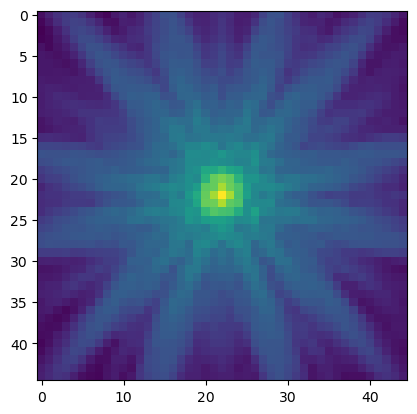

In [97]:
import galsim
import romanisim
print(romanisim.parameters.pixel_scale)

scale = romanisim.parameters.pixel_scale
nx = ny = (int(5 / scale) // 2) * 2 + 1

var_img = temp.drawImage(nx=nx, ny=ny, scale=scale, method="auto")  # auto chooses real/k-space wisely
var_img /= var_img.array.sum()

img = psf.drawImage(nx=nx, ny=ny, scale=scale, method="auto")  # auto chooses real/k-space wisely
img /= img.array.sum()

plt.imshow(np.log10(img.array))

In [105]:
maggytoes = romanisim.bandpass.get_abflux('F158', 2)

In [106]:
642 * maggytoes

np.float64(22662392080044.67)

In [107]:
maggytoes

np.float64(35299676137.141235)

In [11]:
from romanisim import ris_make_utils as ris
from romanisim import log, wcs, persistence, parameters, l3, bandpass, util

In [13]:
center = util.celestialcoord(SkyCoord(ra=0 * u.deg, dec=0 * u.deg))

In [62]:
cat = ris.create_catalog(metadata=None,
                         catalog_name='/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim//sky_jaguar_test/temp/sky_table_sky_jaguar_test.ecsv',
                         bandpasses=['F158'], coord=center, 
                         radius=501)

In [63]:
cat[0].profile.spectral

AttributeError: 'Row' object has no attribute 'profile'

'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim'

In [37]:
dm = rosesim.read_L3_asdf('./F106_11642s.asdf')
# rosesim.utils.asdf_to_fits(dm, 'F158_642s.fits', subtract_bkg=False)

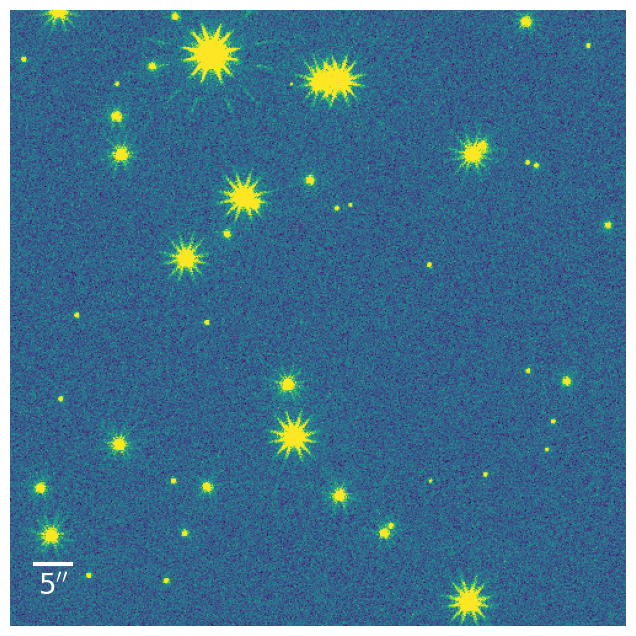

In [38]:
display_single(dm.data);

## 3. Visualize the sky background

In [59]:
from astropy.visualization import make_lupton_rgb

In [60]:
zp = -2.5 * np.log10(1 * ((0.11 * u.arcsec)**2).to(u.steradian).value * 1e6 / 3631)
print(zp)

25.265227862373404


25.265227862373404


25.265227862373404


25.265227862373404


In [61]:
pwd

'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim'

'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim'

'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim'

In [97]:
# os.chdir('../sky_jaguar_trilegal/')
# os.chdir('../empty_sky/')
# os.chdir('../sky_jaguar_trilegal_cena_sizecut/')
# os.chdir('../sky_jaguar_trilegal_cena_backup/')
os.chdir('../sky_jaguar_trilegal_ngc253/')

In [98]:
filters = ['F106', 'F129', 'F158']
imgs = []
exptime = 600
# exptime = 642
# exptime = 10272
# exptime = 2568
# exptime = 2568 * 4
for filt in filters:
    dm = rosesim.read_L3_asdf(f'./{filt}_{exptime}s_LINEGAP5_1.0.asdf')
    img = dm.data - np.median(dm.data)
    img *= 10**(0.4 * (27 - zp))
    imgs.append(img[:, :])

In [49]:
# filt = 'F106'
# imgs = []
# exptime = 642
# exptime = 10272
# # exptime = 2568
# # exptime = 2568 * 4
# for exptime in [642, 5136]:#, 10272]:
#     af = asdf.open(f'./galsim_fast/{filt}_{exptime}s.asdf')
#     dm = rdm.open(af)
#     img = dm.data - np.median(dm.data)
#     img *= 10**(0.4 * (27 - zp))
#     imgs.append(img[:, :])

In [ ]:
display_single(imgs[0][:500, :500]);

In [ ]:
# rgb = make_lupton_rgb(1.0 * imgs[2], 1.05 * imgs[1], 1.2 * imgs[0], minimum=-0.03, stretch=1, Q=4)
rgb = make_lupton_rgb(0.9 * imgs[2], 1.05 * imgs[1], 1.2 * imgs[0], minimum=-0.02, stretch=1, Q=3)
fig, ax = plt.subplots(figsize=(20, 20))
plt.imshow(rgb[:1500, :1500])
plt.axis('off')

# plt.savefig(f'/tigress/jiaxuanl/public_html/figure/SBF/Rosesim/sky_jaguar_cena_stpsf_slow_{exptime}s.png', bbox_inches='tight', dpi=200, transparent=True)
# plt.close()

Check https://tigress-web.princeton.edu/~jiaxuanl/figure/SBF/Rosesim/sky.png

---

In [143]:
dm = rosesim.read_L3_asdf("/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar/F158_642s.asdf")

In [144]:
dm.meta

{'association': {'name': '?'}, 'cal_logs': <roman_datamodels.stnode.CalLogs object at 0x7f3ad447dae0>, 'cal_step': {'flux': 'COMPLETE', 'outlier_detection': 'COMPLETE', 'resample': 'COMPLETE', 'skymatch': 'COMPLETE'}, 'calibration_software_name': 'RomanCAL', 'calibration_software_version': '?', 'coadd_info': {'exposure_time': 642.0, 'individual_image_meta': None, 'max_exposure_time': 642.0, 'time_first': <Time object: scale='utc' format='mjd' value=60675.99628472222>, 'time_last': <Time object: scale='utc' format='mjd' value=60676.00371527778>, 'time_mean': <Time object: scale='utc' format='isot' value=2025-01-01T00:00:00.000>}, 'coordinates': {'reference_frame': 'ICRS'}, 'file_date': <FileDate object: scale='utc' format='isot' value=2020-01-01T00:00:00.000>, 'filename': 'F158_642s.asdf', 'individual_image_meta': {}, 'instrument': {'name': 'WFI', 'optical_element': 'F158'}, 'model_type': 'MosaicModel', 'observation': {'execution_plan': -999999, 'exposure': -999999, 'exposure_grouping':

In [22]:
gwcs = dm.meta.wcs

In [25]:
gwcs.footprint()

array([[150.02843971,   2.19769392],
       [150.02843161,   2.35050203],
       [150.18136839,   2.35050203],
       [150.18136029,   2.19769392]])

In [84]:
obs_ra / 15, obs_dec

(10.006993333333332, 2.2741)